In [1]:
!pip install transformers datasets

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import json
from datasets import Dataset

Mounted at /content/drive


In [ ]:
# Path to dataset
DATA_PATH = "/content/drive/MyDrive/MURIL_Target_label/Dataset/600SentencesHate.json"
entity_data = []

# Load the JSON data from the file
with open(DATA_PATH, 'r') as f:
    data = json.load(f)

for item in data:
    entities = item.get("entities", [])
    labels = item.get("labels", [])
    for e, l in zip(entities, labels):
        if e.strip() != "":
            entity_data.append({"text": e, "label": l})

# Convert to HuggingFace Dataset
dataset = Dataset.from_list(entity_data)
print("Sample entity:", dataset[0])

Sample entity: {'text': 'ஆம்பல', 'label': 1}


In [ ]:
# --------------------------
# Tokenizer & Labels
# --------------------------
from transformers import AutoTokenizer

MODEL_NAME = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Label mapping (0 = Not hate, 1 = Hate)
label_list = [0, 1]
num_labels = len(label_list)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(example):
    tokens = tokenizer(example["text"], truncation=True, padding="max_length", max_length=64)
    tokens["labels"] = [example["label"]]  # sequence classification
    return tokens

tokenized_dataset = dataset.map(tokenize_function)

Map:   0%|          | 0/1508 [00:00<?, ? examples/s]

In [ ]:

# --------------------------
# Model
# --------------------------
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels
)

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/MURIL_Target_26OCT/muril-hate-ner",
    logging_strategy="no",
    save_strategy="no",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,  # tokenized dataset
    tokenizer=tokenizer,
)

trainer.train()

/tmp/ipython-input-1845874651.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 2020csc055 (2020csc055-university-of-jaffna) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss


TrainOutput(global_step=945, training_loss=0.625878841662533, metrics={'train_runtime': 177.3928, 'train_samples_per_second': 42.505, 'train_steps_per_second': 5.327, 'total_flos': 247982169676800.0, 'train_loss': 0.625878841662533, 'epoch': 5.0})

In [ ]:
# Path in your Google Drive to save
save_path = "/content/drive/MyDrive/MURIL_Target_26OCT/muril-entity-hate-final"

# Save model + tokenizer
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}")


Model saved to /content/drive/MyDrive/MURIL_Target_26OCT/muril-entity-hate-final


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load tokenizer & model from Drive
load_path = "/content/drive/MyDrive/MURIL_Target_26OCT/muril-entity-Model-26OCT"

tokenizer = AutoTokenizer.from_pretrained(load_path)
model = AutoModelForSequenceClassification.from_pretrained(load_path)

# Move to GPU if available
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model loaded and ready on device:", device)


Model loaded and ready on device: cuda


In [3]:
import torch
import torch.nn.functional as F

def classify_entities_with_scores(entities):
    results = []
    for entity in entities:
        inputs = tokenizer(entity, return_tensors="pt", truncation=True, padding=True).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits  # [1, num_labels]
            probs = F.softmax(logits, dim=-1).squeeze(0)  # [num_labels]
            hate_score = probs[1].item()
            not_hate_score = probs[0].item()
            label = "HATE" if hate_score > not_hate_score else "NOT_HATE"

            results.append({
                "entity": entity,
                "label": label,
                "HATE_score": round(hate_score, 4),
                "NOT_HATE_score": round(not_hate_score, 4)
            })
    return results



In [ ]:
# Example sentence (for reference only)
test_text = "அப்பா ரிச்சர்ட் நீ கிறித்தவம், உன் தங்கை ஷாலினியை யாருக்காக கல்யாணம் செய்து வைத்தாய், ஒரு இந்துவுக்கு (அஜித்), இப்படி நீயே போன் செய்து ஊருக்கு பாடம் சொல்லாத இந்த படம் பயங்கர தோல்வி"

# Entities you want the model to classify
entities = ["ரிச்சர்ட்", "ஷாலினி", "அஜித்"]

# Pass only the list of entities to the classifier
results = classify_entities_with_scores(entities)
print(results)

[{'entity': 'ரிச்சர்ட்', 'label': 'HATE', 'HATE_score': 0.7471, 'NOT_HATE_score': 0.2529}, {'entity': 'ஷாலினி', 'label': 'HATE', 'HATE_score': 0.7476, 'NOT_HATE_score': 0.2524}, {'entity': 'அஜித்', 'label': 'HATE', 'HATE_score': 0.7468, 'NOT_HATE_score': 0.2532}]


In [4]:
from sklearn.metrics import classification_report, accuracy_score# === 2. Load Test Data ===
TEST_FILE = "/content/drive/MyDrive/MURIL_Target_label/Dataset/target_Test.json"  # change to your test file
with open(TEST_FILE, "r", encoding="utf-8") as f:
    test_data = json.load(f)   # if JSON array


# === 3. Run Predictions ===
y_true, y_pred = [], []

for sample in test_data:
    entities = sample["entities"]
    true_labels = sample["labels"]

    for ent, true_label in zip(entities, true_labels):
        inputs = tokenizer(ent, return_tensors="pt", truncation=True, padding=True).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
            pred_label = torch.argmax(outputs.logits, dim=1).item()

        y_true.append(true_label)
        y_pred.append(pred_label)

# === 4. Report Metrics ===
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Not Target (0)", "Target (1)"]))

Accuracy: 0.72
                precision    recall  f1-score   support

Not Target (0)       0.83      0.45      0.59        11
    Target (1)       0.68      0.93      0.79        14

      accuracy                           0.72        25
     macro avg       0.76      0.69      0.69        25
  weighted avg       0.75      0.72      0.70        25



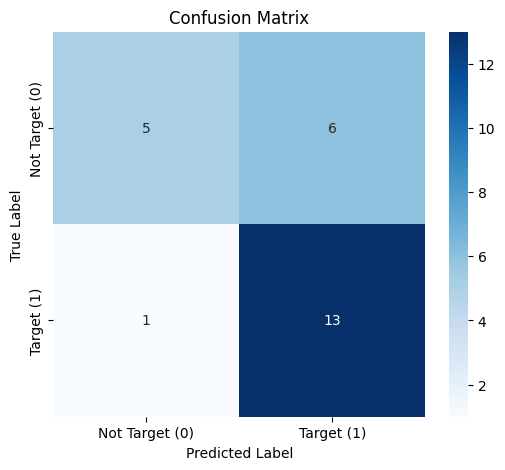

Confusion Matrix:
 [[ 5  6]
 [ 1 13]]


In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# === 5. Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Target (0)", "Target (1)"],
            yticklabels=["Not Target (0)", "Target (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:\n", cm)
